In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "torch"

import math
import numpy as np  
import seaborn as sns
import pandas as pd
import keras
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import truncnorm

import bayesflow as bf
import tensorflow as tf

import DDMChelpers

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
I0000 00:00:1778769633.220366   29111 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
def ddmc_prior(): 
    # as in amortized_dmc.pdf, Updated $sd_r$ fixed, rounded values
    lower = 0
    upper = np.inf

    means = np.array([360, 35, 60, 0.6, 20, 20, 120, 120])
    sds = np.array([25, 8, 13, 0.15, 8, 8, 40, 40])

    a = (lower - means) / sds
    b = (upper - means) / sds

    priors = truncnorm.rvs(a, b, loc=means, scale=sds)

    return dict(mu_r=priors[0], sd_r=priors[1], b=priors[2], muc=priors[3], 
                A1=priors[4], A2=priors[5], tau1=priors[6], tau2=priors[7])


#def ddmc_prior(rng = None): 
#    if rng is None:
#        rng = np.random.default_rng()
#    
#    mu_r    = truncnorm.rvs((0 - 400) / 30, (np.inf - 400) / 30, 400, 30, random_state = rng)
#    sd_r    = truncnorm.rvs((0 - 30) / 10, (np.inf - 30) / 10, 30, 10, random_state = rng)
#    b       = truncnorm.rvs((0 - 80) / 20, (np.inf - 80) / 20, 80, 20, random_state = rng)
#    muc     = rng.beta(2, 2)
#    A1      = truncnorm.rvs((0 - 20) / 8, (np.inf - 20) / 8, 20, 8, random_state = rng)
#    A2      = truncnorm.rvs((0 - 20) / 8, (np.inf - 20) / 8, 20, 8, random_state = rng)
#    tau1    = rng.uniform(20, 180)
#    tau2    = rng.uniform(20, 180)
#    
#
#    return dict(mu_r=mu_r, sd_r=sd_r, b=b, muc=muc, A1=A1, A2=A2, tau1=tau1, 
#                tau2=tau2)


def ddmc_trial(muc, A1, A2, tau1, tau2, b, ndts, noise, t, sigma = 4.0, dt = 1): 
    # Simulate multiple DDMC trials in parallel

    # Prepare output
    num_trials, _ = noise.shape
    rts = np.full(num_trials, -1.0)
    resps = np.full(num_trials, -1)

    X0 = np.random.beta(3, 3, size=num_trials) * (2 * b) - b    # initial pos

    # with a1 = a2 = 2
    mu_a1 = A1 / tau1 * np.exp(1 - t / tau1) * (1 - t / tau1)
    mu_a2 = A2 / tau2 * np.exp(1 - t / tau2) * (1 - t / tau2)
    mu_t = mu_a1 + mu_a2 + muc

    dX = mu_t[None, :] * dt + sigma * np.sqrt(dt) * noise

    X = np.cumsum(dX, axis=1) + X0[:, None]

    crossed_upper = X >= b
    crossed_lower = X <= -b
    crossed_any = crossed_upper | crossed_lower

    # First crossing index for each trial
    first_crossing = np.argmax(crossed_any, axis=1)
    has_crossed = np.any(crossed_any, axis=1)

    # Fill only for trials that crossed
    idx = np.where(has_crossed)[0]
    crossing_times = t[first_crossing[idx]]


    ndts_crossed = ndts[idx]    # nondecision times only for trials that crossed
    rts[idx] = (crossing_times + ndts_crossed) / 1000  # convert to seconds

    # get response type
    resp_hit = X[idx, first_crossing[idx]]
    resps[idx] = (resp_hit >= b).astype(int)

    return np.c_[rts, resps]


def ddmc_experiment(num_obs, muc, A1, A2, tau1, tau2, b, mu_r, sd_r): 
    max_time = 1500
    dt = 1

    # precompute time vector and noise
    t = np.arange(start=dt, stop=max_time+dt, step=dt)
    noise = np.random.normal(size = (num_obs, len(t)))
#    ndts = np.random.normal(size = num_obs, loc=mu_r, scale=sd_r)
    ndts = truncnorm.rvs((0 - mu_r) / sd_r, (np.inf - mu_r) / sd_r, mu_r, sd_r, size=num_obs)

    out = np.zeros((num_obs, 2))        # to store rt and resp

    # congruency conditions (equal split)
    quarter = int(np.ceil(num_obs / 4))
    conditions = np.repeat(np.arange(4), quarter)[:num_obs]

    # simulate CONG-CONG trials (A1, A2)
    out[:quarter] = ddmc_trial(
        muc=muc, A1=A1, A2=A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[:quarter], noise=noise[:quarter]
    )
    # simulate CONG-INCONG trials (A1, -A2)
    out[quarter:quarter*2] = ddmc_trial(
        muc=muc, A1=A1, A2=-A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter:quarter*2], noise=noise[quarter:quarter*2]
    )
    # simulate INCONG-CONG trials (-A1, A2)
    out[quarter*2:quarter*3] = ddmc_trial(
        muc=muc, A1=-A1, A2=A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter*2:quarter*3], noise=noise[quarter*2:quarter*3]
    )
    # simulate INCONG-INCONG trials (-A1, -A2)
    out[quarter*3:] = ddmc_trial(
        muc=muc, A1=-A1, A2=-A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter*3:], noise=noise[quarter*3:]
    )

    # contaminate
    cont_rt = np.abs(np.random.standard_t(df = 1, size = num_obs))
    cont_resp = np.random.binomial(n = 1, p = 0.5, size = num_obs)

    cont_prob = 0.1
    replace = np.random.binomial(n = 1, p = cont_prob, size = num_obs)

    out[:, 0] = (1-replace)*out[:, 0] + replace*cont_rt
    out[:, 1] = (1-replace)*out[:, 1] + replace*cont_resp

    return dict(rt = out[:, 0], resp = out[:, 1], conditions = conditions, 
    num_obs = num_obs)

# Number of observations (trials) in each batch randomly sampled
def meta(batch_size, num_obs = None): 
    if num_obs == None:
        num_obs = np.random.randint(50, 800)
    return dict(num_obs = num_obs)
    
ddmc_experiment(num_obs = 12, muc = 0.5, A1 = 60, A2 = 60, 
tau1 = 10, tau2 = 170, b = 70, mu_r = 300, sd_r = 30)

#priors = ddmc_prior()
#for i in priors.items():
#    print(i)


{'rt': array([0.34168188, 0.29773267, 0.39933902, 0.33204179, 0.27858369,
        0.29519289, 0.35417341, 0.51990681, 0.3749551 , 0.32305639,
        0.34330141, 0.32628892]),
 'resp': array([1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0.]),
 'conditions': array([0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3]),
 'num_obs': 12}

In [ ]:
simulator = bf.simulators.make_simulator([ddmc_prior, ddmc_experiment], meta_fn = meta)

sim_data = simulator.sample(64)
print("Shape of rt:", sim_data["rt"].shape)
print("Shape of response:", sim_data["resp"].shape)
print("Shape of condition:", sim_data["conditions"].shape)

Shape of rt: (64, 590)
Shape of response: (64, 590)
Shape of condition: (64, 590)


In [5]:
approximator = keras.saving.load_model("out/DDMC_2000.keras")

#### Load Data

In [6]:
directory_1a = "../data/raw/Exp1a_data/combi/"      # Flanker x Stroop
directory_1b = "../data/raw/Exp1b_data/combi/"      # Flanker x Stroop
directory_1c = "../data/raw/Exp1c_data/combi/"      # Flanker x Stroop
directory_2 = "../data/raw/Exp2_data/combi/"        # Simon x Stroop
directory_3 = "../data/raw/Exp3_data/combi/"        # Flanker x Simon

filelist_1a = os.listdir(directory_1a)
filelist_1b = os.listdir(directory_1b)
filelist_1c = os.listdir(directory_1c)
filelist_2 = os.listdir(directory_2)
filelist_3 = os.listdir(directory_3)

colnames_1a = [
    "subject", "block", "catch", "stimulus", "stimuluscolor", "flankercolor", 
    "flanker", "stroop", "xr", "resp", "corr", "rt", "re"
]
colnames_1b = [
    "subject", "block", "catch", "stimulus", "stimuluscolor", "flankercolor", 
    "flanker", "stroop", "stroopstimulusnumber", "flankerstimulusnumber", 
    "stimulusnumber", "xr", "resp", "corr", "rt", "re"
]
colnames_1c = [
    "subject", "block", "trial", "catch", "stimulus", "stimuluscolor", 
    "flankercolor", "flanker", "stroop", "xr", "resp", "corr", "rt", "re"
]
colnames_2 = [
    "subject", "block", "catch", "stimulus", "stimuluscolor", "stimulusposition", 
    "simon", "stroop", "xr", "resp", "corr", "rt", "re"
]
colnames_3 = [
    "subject", "block", "stimulus", "flankercolor", "stimulusposition", 
    "simon", "flanker", "xr", "resp", "corr", "rt", "re"
]

df_1a = DDMChelpers.read_ReyMermetGade(directory_1a, filelist_1a, colnames_1a, "flanker", "stroop")
#df_1b = read_ReyMermetGade(directory_1b, filelist_1b, colnames_1b, "flanker", "stroop")
#df_1c = read_ReyMermetGade(directory_1c, filelist_1c, colnames_1c, "flanker", "stroop")

df_2 = DDMChelpers.read_ReyMermetGade(directory_2, filelist_2, colnames_2, "simon", "stroop")

df_3 = DDMChelpers.read_ReyMermetGade(directory_3, filelist_3, colnames_3, "simon", "flanker")

# exclude catch trials
df_1a = df_1a.drop(df_1a[df_1a.catch == 1].index)
#df_1b = df_1b.drop(df_1b[df_1b.catch == 1].index)
#df_1c = df_1c.drop(df_1c[df_1c.catch == 1].index)
df_2 = df_2.drop(df_2[df_2.catch == 1].index)

# drop unused columns
#df_1a.drop(['block', 'catch', 're', 'xr'], inplace=True, axis=1)


# rt outlier exclusion, timeout responses
df_1a = df_1a[(df_1a["rt"] < 1.5) & (df_1a["rt"] > 0.3) & (df_1a["resp"] != 0)]
#df_1b = df_1b[(df_1b["rt"] < 2.0) & (df_1b["rt"] > 0.3) & (df_1b["resp"] != 0)]
#df_1c = df_1c[(df_1c["rt"] < 2.0) & (df_1c["rt"] > 0.3) & (df_1c["resp"] != 0)]
df_2 = df_2[(df_2["rt"] < 1.5) & (df_2["rt"] > 0.3) & (df_2["resp"] != 0)]
df_3 = df_3[(df_3["rt"] < 1.5) & (df_3["rt"] > 0.3) & (df_3["resp"] != 0)]


#print(df_3)
#print(df_2)
#print(df_1a)
#print(df_1b)
#print(df_1c)

In [25]:
test_data = simulator.sample(500)

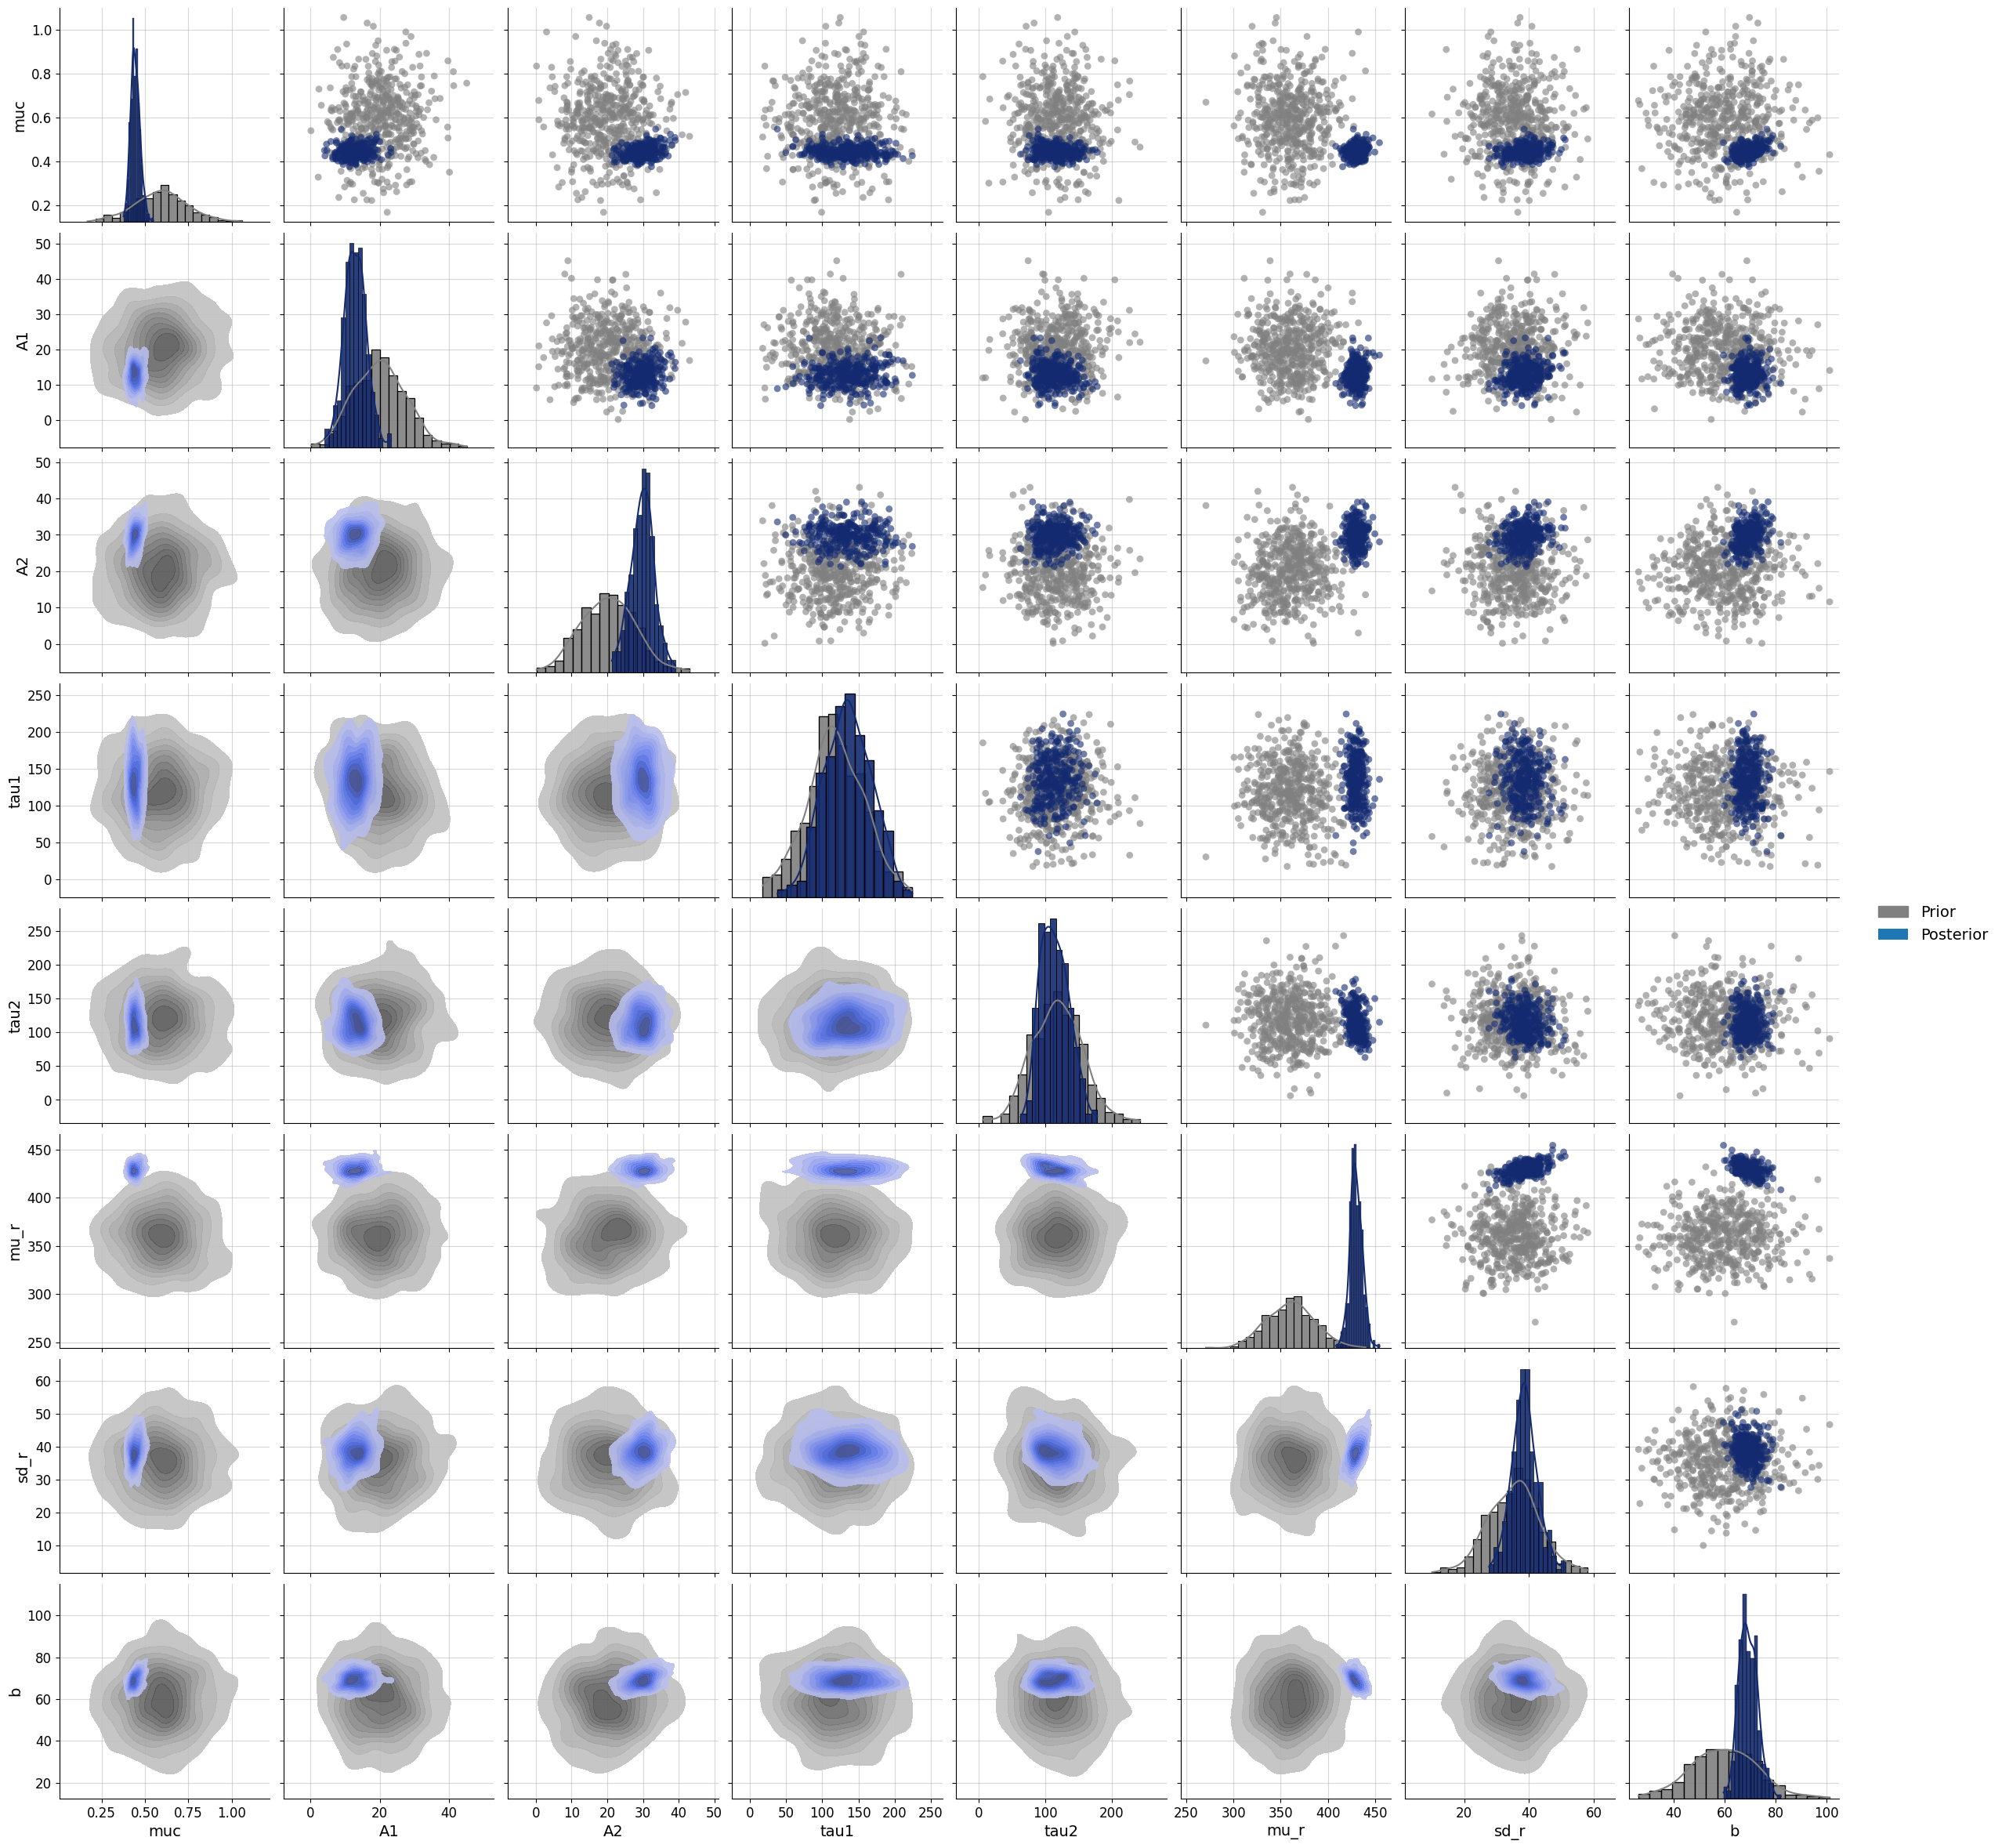

In [ ]:
posterior = {key: value[0] for key, value in post_draws.items()}  # 1st participant
priors = dict(
    muc=test_data["muc"], A1=test_data["A1"], A2=test_data["A2"],
    tau1=test_data["tau1"], tau2=test_data["tau2"],
    mu_r=test_data["mu_r"], sd_r=test_data["sd_r"],
    b=test_data["b"]
)

f=bf.diagnostics.pairs_posterior(estimates=posterior, priors=priors)

In [ ]:
part_samples_1a, preds_1a = DDMChelpers.pred_samples_participants(df_1a, approximator)

In [ ]:
part_samples_2, preds_2 = DDMChelpers.pred_samples_participants(df_2, approximator)

In [ ]:
#TODO look into hierarchical
part_samples_3, preds_3 = DDMChelpers.pred_samples_participants(df_3, approximator)

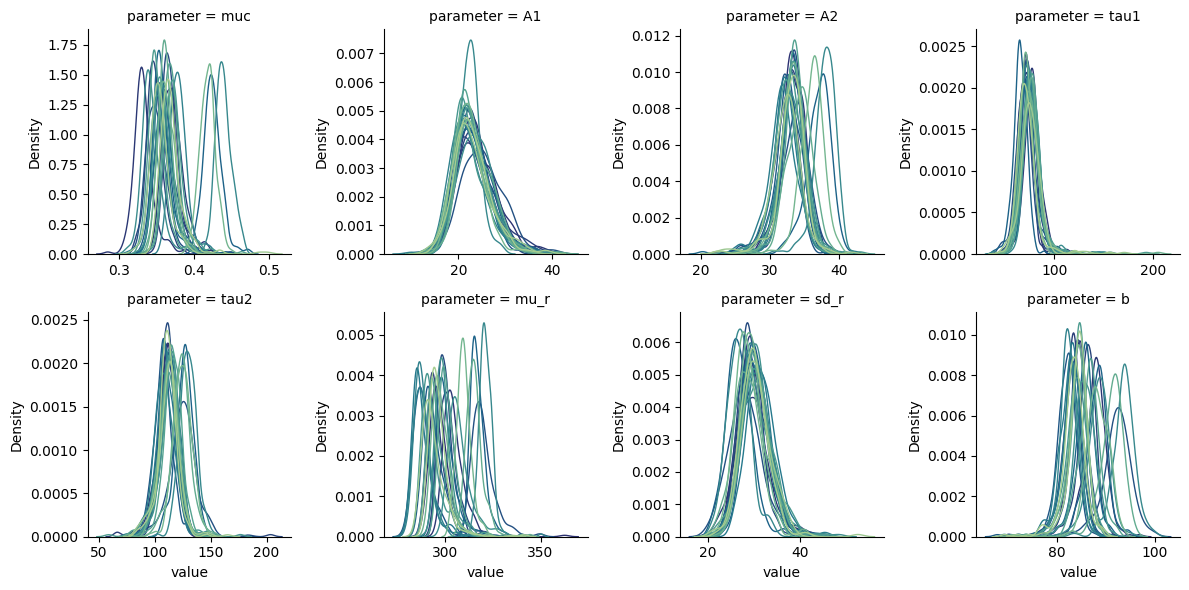

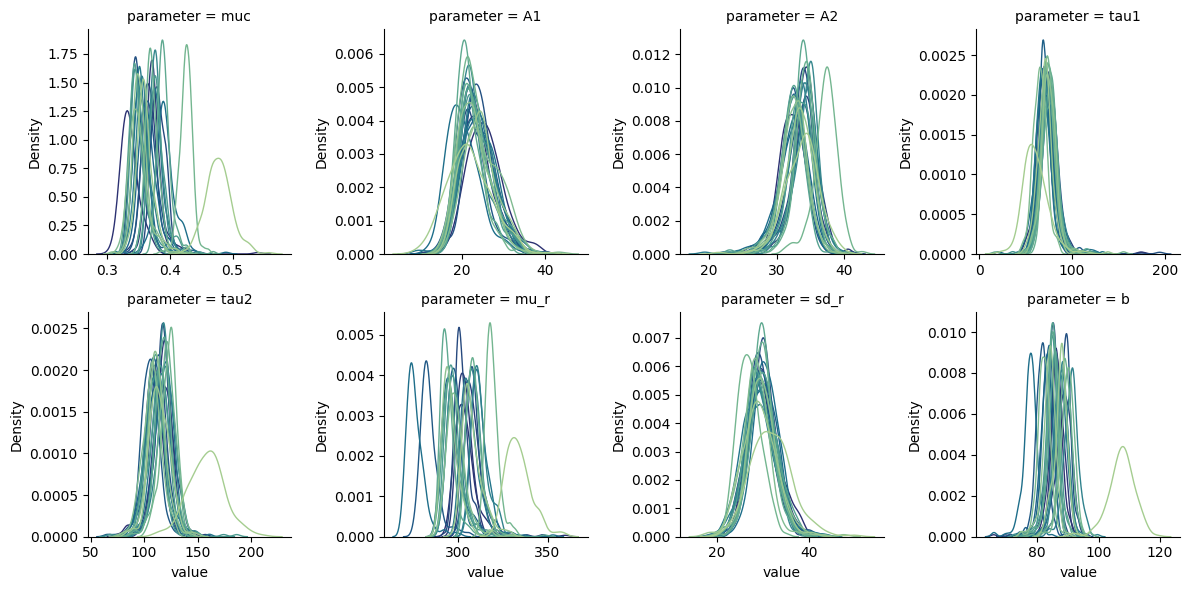

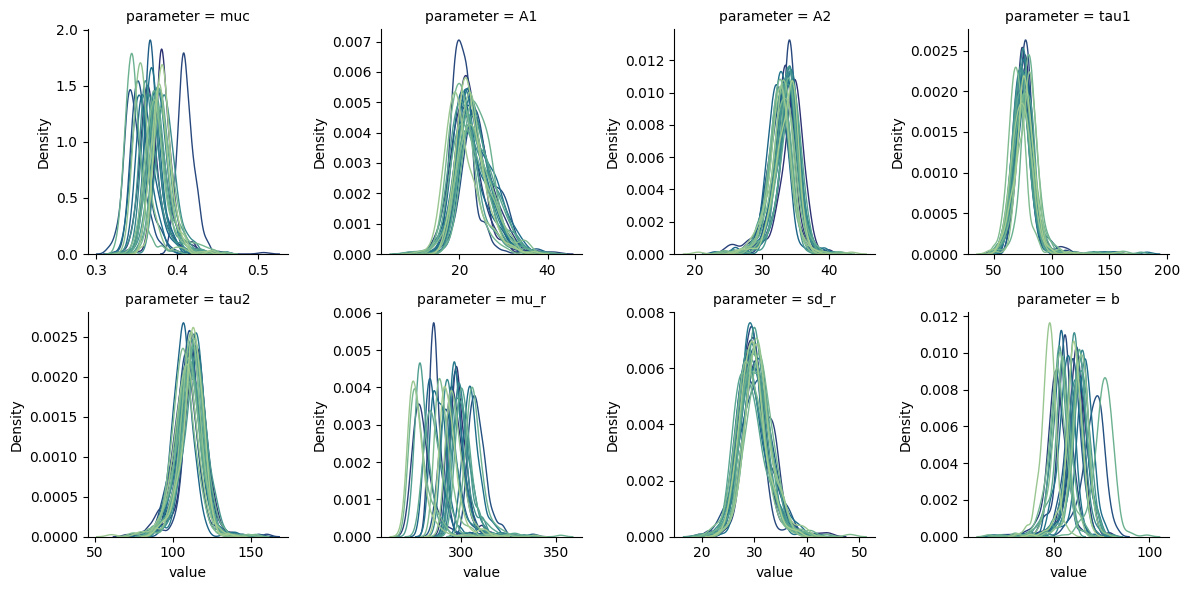

In [ ]:
def plot_params_part(data):

    df_long = data.melt(
        id_vars="subject",
        value_vars=["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"],
        var_name="parameter",
        value_name="value"
    )

    f = sns.FacetGrid(
        df_long, col="parameter", col_wrap=4, sharex=False, sharey=False
    )
    f.map_dataframe(
        sns.kdeplot, 
        x="value", hue="subject", 
        linewidth=1, palette = "crest"
    )

    return f

plot_params_part(part_samples_1a)
plot_params_part(part_samples_2)
plot_params_part(part_samples_3)

In [ ]:
# per subject RTs prediction vs empirical 
DDMChelpers.plt_subjs_emp(df_1a, preds_1a) 
DDMChelpers.plt_subjs_emp(df_2, preds_2) 
DDMChelpers.plt_subjs_emp(df_3, preds_3) 

In [ ]:
# CDFs
sns.ecdfplot(df_3, x="rt", linewidth=1, hue="subject")
sns.ecdfplot(preds_3, x="rt", linewidth=1, hue="subject", palette="crest")
plt.ylim(0, 1)
plt.xlabel("RT")
plt.ylabel("Probability")
plt.title("Empirical CDF")
plt.show()

In [ ]:
cond_samples_1a, cond_preds_1a = DDMChelpers.pred_samples_conditions(df_1a, approximator)
cond_samples_2, cond_preds_2 = DDMChelpers.pred_samples_conditions(df_2, approximator)
cond_samples_3, cond_preds_3 = DDMChelpers.pred_samples_conditions(df_3, approximator)

In [ ]:
DDMChelpers.plt_conds_emp(df_1a, cond_preds_1a)
DDMChelpers.plt_conds_emp(df_2, cond_preds_2)
DDMChelpers.plt_conds_emp(df_3, cond_preds_3)

In [ ]:
def plot_params_conds(data):

    df_long = data.melt(
    id_vars="CI",
    value_vars=["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"],
    var_name="parameter",
    value_name="value"
    )

    f = sns.FacetGrid(
        df_long,
        col="parameter",
        col_wrap=4, 
        hue="CI",
        sharex=False,
        sharey=False
    )
    f.map_dataframe(sns.kdeplot, x="value", linewidth=1.5)
    f.add_legend(title="Condition")

plot_params_conds(cond_samples_1a)
plot_params_conds(cond_samples_2)
plot_params_conds(cond_samples_3)

In [ ]:
def get_samples(data): 
    inference_dict = {
        key: np.array([data[key].values.reshape(len(data), 1)]) 
        for key in ['rt', 'resp', 'conditions']
        }
    inference_dict["num_obs"] = np.sum(inference_dict["rt"], axis=1)
    print({key: value.shape for key, value in inference_dict.items()}) # shapes

    samples = approximator.sample(conditions=inference_dict, num_samples=200)
    return samples

samples_1a = get_samples(df_1a)
samples_2 = get_samples(df_2)
samples_3 = get_samples(df_3)

In [ ]:
def plot_samples(samples):
    samples_flat = {k: v.flatten() for k, v in samples.items()}

    params = list(samples_flat.keys())


    f, axarr = plt.subplots(2, 4, figsize=(12, 4))
    for i in range(len(params)):
        ax = axarr.flat[i]
        sns.kdeplot(samples_flat[params[i]], ax=ax)
        ax.set_title(f"{params[i]}")
        ax.set_xlabel(params[i])
        ax.set_ylabel("Density")

    plt.tight_layout()
    plt.show()

plot_samples(samples_1a)
plot_samples(samples_2)
plot_samples(samples_3)